In [1]:
# Cell 1: Installations
!pip install -q medmnist open_clip_torch faiss-cpu matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 84.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 91.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 5.1 MB/s eta 0:00:00


In [2]:
# Cell 2: Import Libraries & Load Model
import torch
import open_clip
import faiss
import numpy as np
import matplotlib.pyplot as plt
from medmnist import PneumoniaMNIST
from PIL import Image

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Load BiomedCLIP and its tokenizer
print("Loading BiomedCLIP model from Hugging Face...")
model_id = 'hf-hub:microsoft/BiomedCLIP-PubMedBERT_256-vit_base_patch16_224'
model, preprocess_train, preprocess_val = open_clip.create_model_and_transforms(model_id)
tokenizer = open_clip.get_tokenizer(model_id)

model = model.to(device)
model.eval()
print("Model loaded successfully!")

Using device: cuda
Loading BiomedCLIP model from Hugging Face...


open_clip_config.json:   0%|          | 0.00/707 [00:00<?, ?B/s]

open_clip_pytorch_model.bin:   0%|          | 0.00/784M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/28.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

Model loaded successfully!


In [3]:
# Cell 3: Extract Embeddings
print("Loading PneumoniaMNIST test set...")
test_dataset = PneumoniaMNIST(split='test', download=True, size=28)

images = []
labels = []
features = []

print(f"Extracting embeddings for {len(test_dataset)} images. This may take a moment...")
with torch.no_grad():
    for i in range(len(test_dataset)):
        img, label = test_dataset[i]

        # Keep original image for visualization, but preprocess for the model
        images.append(img)
        labels.append(label[0])

        # BiomedCLIP expects RGB images
        img_rgb = img.convert('RGB')
        img_tensor = preprocess_val(img_rgb).unsqueeze(0).to(device)

        # Extract and L2-normalize the image features
        img_features = model.encode_image(img_tensor)
        img_features /= img_features.norm(dim=-1, keepdim=True)

        features.append(img_features.cpu().numpy().squeeze())

features = np.array(features).astype('float32')
labels = np.array(labels)
print(f"Extraction complete! Feature matrix shape: {features.shape}")

Loading PneumoniaMNIST test set...


100%|██████████| 4.17M/4.17M [00:01<00:00, 3.31MB/s]


Extracting embeddings for 624 images. This may take a moment...
Extraction complete! Feature matrix shape: (624, 512)


In [4]:
# Cell 4: Build Vector Index
embedding_dim = features.shape[1]

# Initialize FAISS index for Inner Product (Cosine Similarity)
index = faiss.IndexFlatIP(embedding_dim)
index.add(features)

print(f"FAISS Vector Database built successfully! Total images indexed: {index.ntotal}")

FAISS Vector Database built successfully! Total images indexed: 624


Testing Image-to-Image Retrieval...


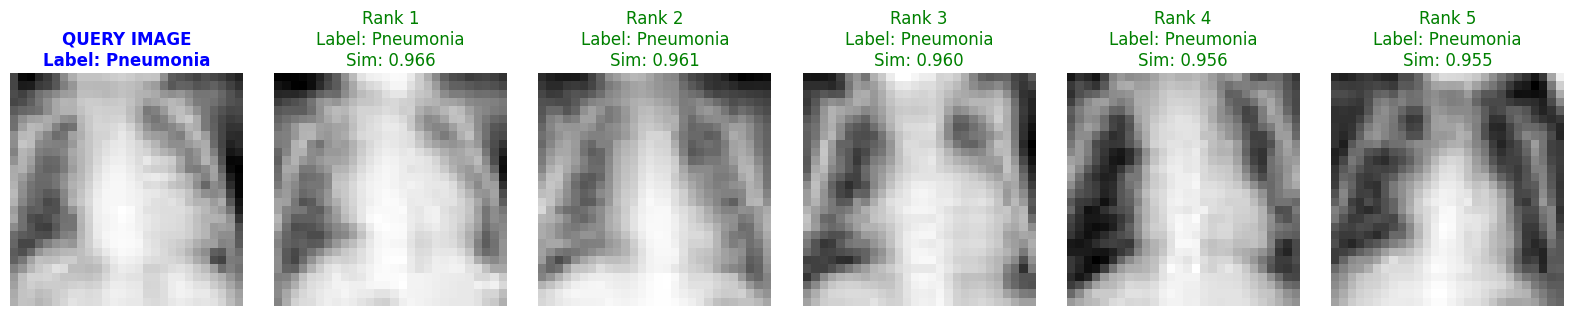

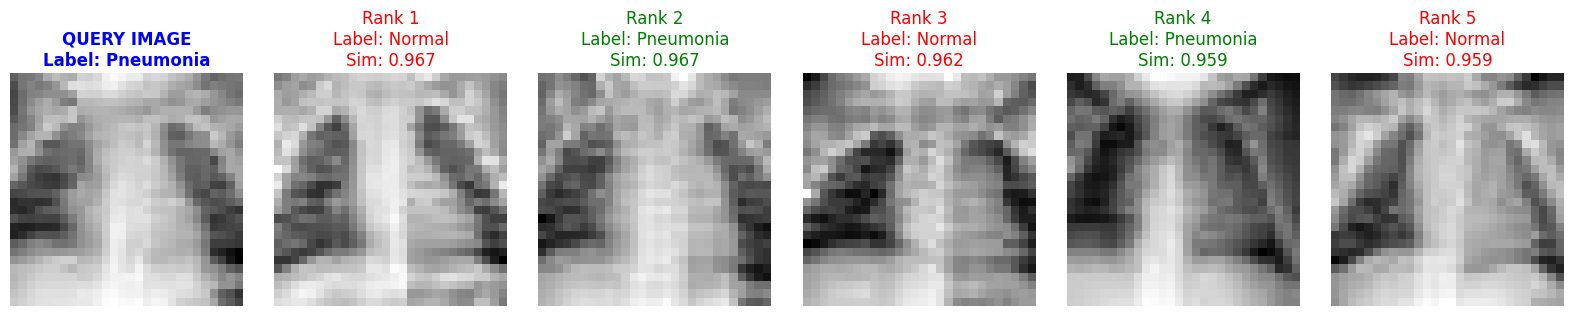

In [5]:
# Cell 5: Image-to-Image Search Interface
def image_to_image_search(query_idx, k=5):
    query_feature = features[query_idx].reshape(1, -1)

    # We search for k+1 because the query image itself will always be the #1 match in the database
    distances, indices = index.search(query_feature, k+1)

    # Drop the first result (the query image itself) to get the true top-k neighbors
    top_k_indices = indices[0][1:]
    top_k_distances = distances[0][1:]

    fig, axes = plt.subplots(1, k+1, figsize=(16, 3))
    query_label = "Pneumonia" if labels[query_idx] == 1 else "Normal"

    # Plot Query
    axes[0].imshow(images[query_idx], cmap='gray')
    axes[0].set_title(f"QUERY IMAGE\nLabel: {query_label}", color='blue', fontweight='bold')
    axes[0].axis('off')

    # Plot Results
    for i, idx in enumerate(top_k_indices):
        retrieved_label = "Pneumonia" if labels[idx] == 1 else "Normal"
        color = 'green' if retrieved_label == query_label else 'red'

        axes[i+1].imshow(images[idx], cmap='gray')
        axes[i+1].set_title(f"Rank {i+1}\nLabel: {retrieved_label}\nSim: {top_k_distances[i]:.3f}", color=color)
        axes[i+1].axis('off')

    plt.tight_layout()
    plt.show()

print("Testing Image-to-Image Retrieval...")
# Let's test one Normal case and one Pneumonia case
image_to_image_search(query_idx=0, k=5)  # Generally Normal
image_to_image_search(query_idx=22, k=5) # Known Pneumonia case from your previous task

tokenizer_config.json:   0%|          | 0.00/394 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

Testing Text-to-Image Retrieval...


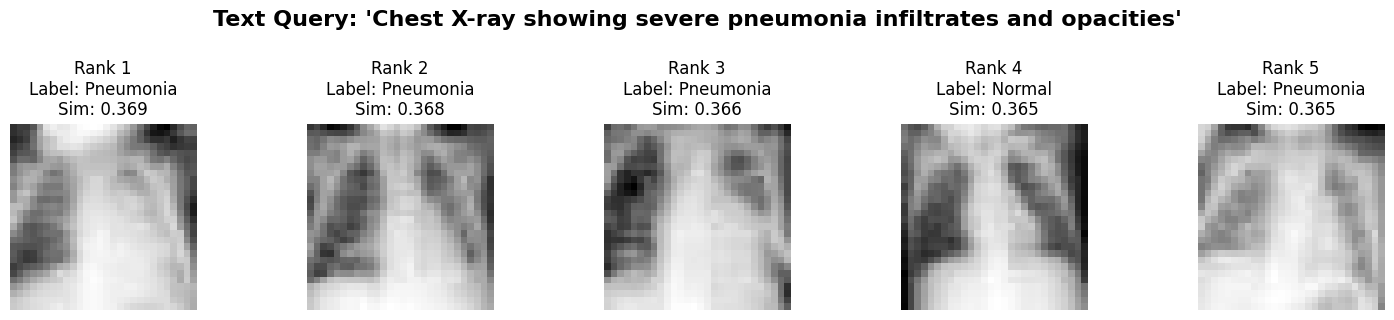

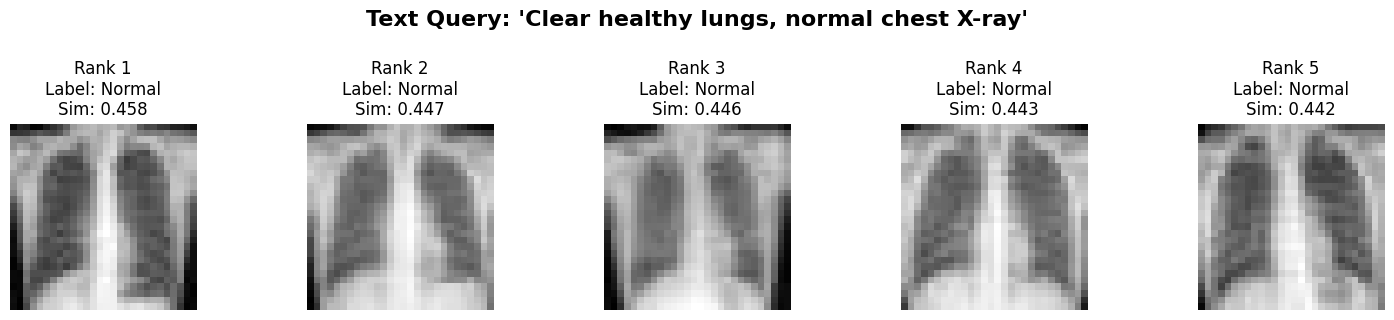

In [7]:
# Cell 6: Text-to-Image Search Interface (Corrected)
from transformers import AutoTokenizer
import matplotlib.pyplot as plt
import torch

# 1. Load the native Hugging Face tokenizer to bypass the open_clip bug
hf_tokenizer = AutoTokenizer.from_pretrained("microsoft/BiomedCLIP-PubMedBERT_256-vit_base_patch16_224")

def text_to_image_search(text_query, k=5):
    # 2. Encode the text query using native transformers AutoTokenizer
    tokens = hf_tokenizer(
        [text_query],
        padding="max_length",
        truncation=True,
        max_length=256,
        return_tensors="pt"
    )

    # Extract just the input IDs and move to GPU/CPU
    text_tokens = tokens.input_ids.to(device)

    with torch.no_grad():
        text_features = model.encode_text(text_tokens)
        text_features /= text_features.norm(dim=-1, keepdim=True) # Normalize

    text_feature_np = text_features.cpu().numpy().astype('float32')

    # 3. Search the FAISS index
    distances, indices = index.search(text_feature_np, k)

    top_k_indices = indices[0]
    top_k_distances = distances[0]

    fig, axes = plt.subplots(1, k, figsize=(15, 3))
    fig.suptitle(f"Text Query: '{text_query}'", fontsize=16, y=1.05, fontweight='bold')

    # 4. Plot Results
    for i, idx in enumerate(top_k_indices):
        retrieved_label = "Pneumonia" if labels[idx] == 1 else "Normal"
        axes[i].imshow(images[idx], cmap='gray')
        axes[i].set_title(f"Rank {i+1}\nLabel: {retrieved_label}\nSim: {top_k_distances[i]:.3f}")
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()

print("Testing Text-to-Image Retrieval...")
text_to_image_search("Chest X-ray showing severe pneumonia infiltrates and opacities", k=5)
text_to_image_search("Clear healthy lungs, normal chest X-ray", k=5)

In [8]:
# Cell 7: Evaluate Precision@k
def evaluate_precision_at_k(k=5):
    print(f"Evaluating Precision@{k} across all {len(features)} test images...")

    # FAISS can efficiently search all queries at once
    distances, indices = index.search(features, k+1)

    precisions = []

    for i in range(len(features)):
        query_label = labels[i]

        # Exclude the first result (which is just the query matching itself)
        retrieved_indices = indices[i][1:]
        retrieved_labels = labels[retrieved_indices]

        # Count how many of the retrieved images match the query's ground truth label
        matches = np.sum(retrieved_labels == query_label)
        precision = matches / k
        precisions.append(precision)

    mean_precision = np.mean(precisions) * 100

    print("-" * 40)
    print(f"SYSTEM RETRIEVAL PERFORMANCE")
    print("-" * 40)
    print(f"Total Queries: {len(features)}")
    print(f"Mean Precision@{k}: {mean_precision:.2f}%")
    print("-" * 40)
    print("Discussion Point for Markdown: A high Precision@k score indicates that the BiomedCLIP embeddings successfully cluster identical pathologies together in the latent vector space, making this a reliable tool for finding 'similar clinical cases'.")

evaluate_precision_at_k(k=5)

Evaluating Precision@5 across all 624 test images...
----------------------------------------
SYSTEM RETRIEVAL PERFORMANCE
----------------------------------------
Total Queries: 624
Mean Precision@5: 85.29%
----------------------------------------
Discussion Point for Markdown: A high Precision@k score indicates that the BiomedCLIP embeddings successfully cluster identical pathologies together in the latent vector space, making this a reliable tool for finding 'similar clinical cases'.
